<a href="https://colab.research.google.com/github/subham-28/ML/blob/main/kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import files
uploaded = files.upload()

Saving final.csv to final (1).csv


In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

df=pd.read_csv("final.csv")

In [15]:
df.head()

,Company's Name,Risk Tolerant Score (1-10),Resilience Score (1-10),Decision Making Speed (hrs),Adaptability (1-10),No of hrs per month spend with mentor,Funding Secured,Prev Entrepreneurial Experience (yes/no),Education,Networking Level (low/med/high),Sustainability (yes/no),Success
0,Meesho Superstore,7,6,24,7,10,Yes,No,"B.Tech (Electrical Engg., IIT Delhi)",Med,No,Yes
1,Flipkart,9,8,12,9,20,Yes,Yes,MBA (IIT Delhi + ISB),High,Yes,Yes
2,Doodhwala,6,5,48,5,5,Yes,No,NaN,Low,No,No
3,Nykaa,8,7,18,8,15,Yes,Yes,MBA (IIM Ahmedabad),High,Yes,Yes
4,Koinex,9,4,72,6,8,No,No,B.Tech (IIT Bombay),Med,No,No


In [16]:
df['Education'] = df['Education'].replace('', 'Unknown')

le = LabelEncoder()
df['Sustainability'] = le.fit_transform(df['Sustainability (yes/no)'])

print("Columns after encoding 'Sustainability':", df.columns.tolist())
if 'Sustainability' not in df.columns:
    raise ValueError("'Sustainability' column was not created successfully.")


Columns after encoding 'Sustainability': ["Company's Name", 'Risk Tolerant Score (1-10)', 'Resilience Score (1-10)', 'Decision Making Speed (hrs)', 'Adaptability (1-10)', 'No of hrs per month spend with mentor', 'Funding Secured', 'Prev Entrepreneurial Experience (yes/no)', 'Education', 'Networking Level (low/med/high)', 'Sustainability (yes/no)', 'Success', 'Sustainability']


In [17]:
features = [
    'Risk Tolerant Score (1-10)', 'Resilience Score (1-10)', 'Decision Making Speed (hrs)',
    'Adaptability (1-10)', 'No of hrs per month spend with mentor', 'Sustainability'
]

missing_features = [f for f in features if f not in df.columns]
if missing_features:
    raise ValueError(f"Features {missing_features} not found in DataFrame columns: {df.columns.tolist()}")

X = df[features]

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

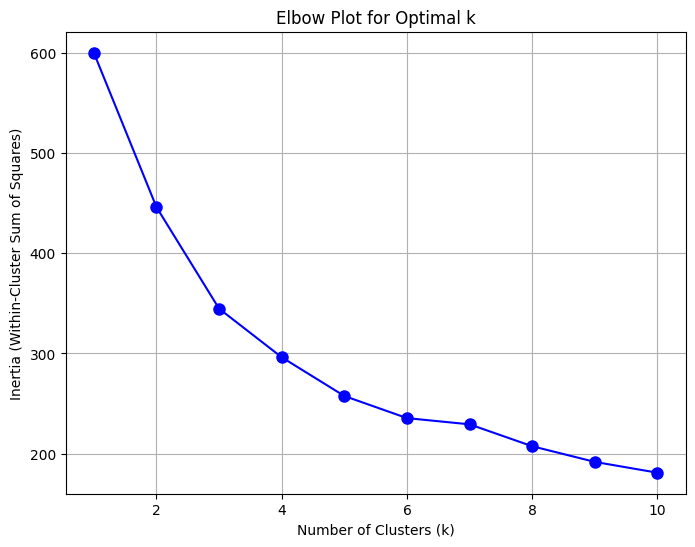

In [19]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Plot for Optimal k')
plt.grid(True)
plt.savefig('elbow_plot.png')
plt.show()

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [21]:
df['Cluster'] = clusters

print("Columns after adding 'Cluster':", df.columns.tolist())
if 'Cluster' not in df.columns:
    raise ValueError("'Cluster' column was not created successfully.")

Columns after adding 'Cluster': ["Company's Name", 'Risk Tolerant Score (1-10)', 'Resilience Score (1-10)', 'Decision Making Speed (hrs)', 'Adaptability (1-10)', 'No of hrs per month spend with mentor', 'Funding Secured', 'Prev Entrepreneurial Experience (yes/no)', 'Education', 'Networking Level (low/med/high)', 'Sustainability (yes/no)', 'Success', 'Sustainability', 'Cluster']


<Axes: >

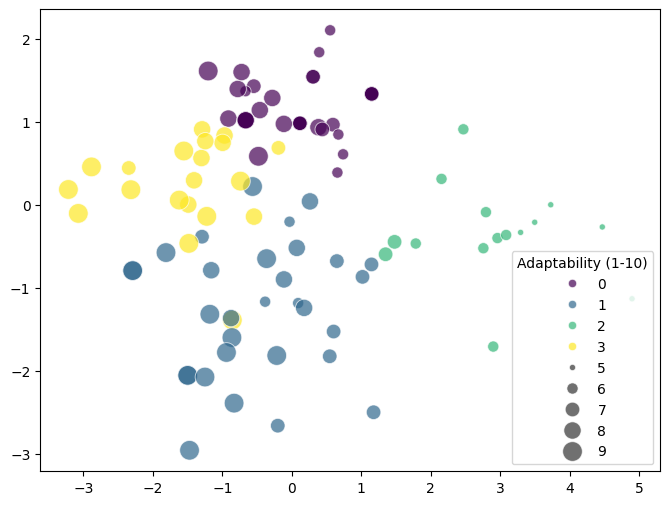

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=clusters,
    palette='viridis',
    size=df['Adaptability (1-10)'],
    sizes=(20, 200),
    alpha=0.7
)

<ipython-input-23-8e4a1cdc09fe>:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Cluster')


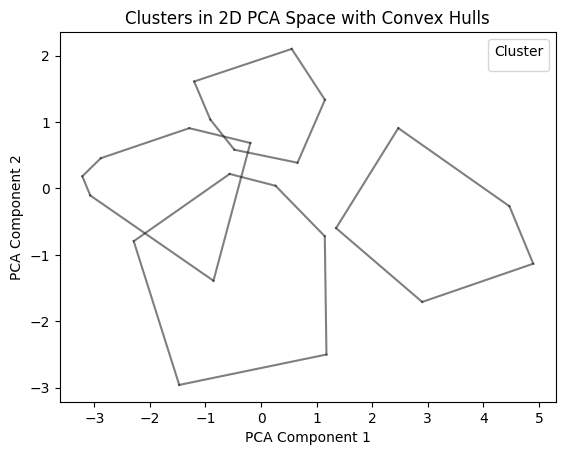

In [23]:
from scipy.spatial import ConvexHull

for cluster in range(4):
    cluster_points = X_pca[clusters == cluster]
    if len(cluster_points) < 4:
        continue
    hull = ConvexHull(cluster_points)
    for simplex in hull.simplices:
        plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], 'k-', alpha=0.5)

plt.title('Clusters in 2D PCA Space with Convex Hulls')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.savefig('scatterplot_pca_convex_hulls.png')
plt.show()


In [24]:
print("Cluster Summaries:")
for cluster in range(1,5):
    print(f"\nCluster {cluster}:")
    cluster_data = df[df['Cluster'] == cluster]
    print(f"Columns in filtered DataFrame for Cluster {cluster}:", cluster_data.columns.tolist())
    print(cluster_data[features].mean())

print("Total Variance Explained (2D PCA):", sum(pca.explained_variance_ratio_))

Cluster Summaries:

Cluster 1:
Columns in filtered DataFrame for Cluster 1: ["Company's Name", 'Risk Tolerant Score (1-10)', 'Resilience Score (1-10)', 'Decision Making Speed (hrs)', 'Adaptability (1-10)', 'No of hrs per month spend with mentor', 'Funding Secured', 'Prev Entrepreneurial Experience (yes/no)', 'Education', 'Networking Level (low/med/high)', 'Sustainability (yes/no)', 'Success', 'Sustainability', 'Cluster']
Risk Tolerant Score (1-10)                7.612903
Resilience Score (1-10)                   5.870968
Decision Making Speed (hrs)              21.677419
Adaptability (1-10)                       8.000000
No of hrs per month spend with mentor    14.225806
Sustainability                            0.000000
dtype: float64

Cluster 2:
Columns in filtered DataFrame for Cluster 2: ["Company's Name", 'Risk Tolerant Score (1-10)', 'Resilience Score (1-10)', 'Decision Making Speed (hrs)', 'Adaptability (1-10)', 'No of hrs per month spend with mentor', 'Funding Secured', 'Prev E